In [1]:
import pandas as pd
import geopandas as gpd
import folium
import json

# Load data
master = pd.read_csv('../data/processed/master_scores.csv')
neighborhoods = gpd.read_file('../data/raw/neighborhoods.geojson')

# Merge scores with neighborhood boundaries
map_data = neighborhoods.merge(master, left_on='name', right_on='neighborhood', how='left')

print(map_data.shape)
map_data[['name', 'final_score']].head()

(26, 21)


,name,final_score
0,Roslindale,0.477271
1,Jamaica Plain,0.624113
2,Mission Hill,0.563742
3,Longwood,NaN
4,Bay Village,NaN


In [2]:
# Create base map centered on Boston
m = folium.Map(location=[42.3601, -71.0589], zoom_start=12)

# Add neighborhoods colored by score
folium.Choropleth(
    geo_data=map_data.to_json(),
    data=master,
    columns=['neighborhood', 'final_score'],
    key_on='feature.properties.name',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Neighborhood Score for BU Students',
    nan_fill_color='gray'
).add_to(m)

# Save map
m.save('../outputs/neighborhood_map.html')
print("Map saved!")

Map saved!


In [3]:
import pandas as pd
import geopandas as gpd
import folium

# Load data
master = pd.read_csv('../data/processed/master_scores.csv')
neighborhoods = gpd.read_file('../data/raw/neighborhoods.geojson')

# Add Brookline boundary
import osmnx as ox
brookline = ox.geocode_to_gdf('Brookline, Massachusetts, USA')
brookline['name'] = 'Brookline'

# Combine Boston neighborhoods with Brookline
neighborhoods = pd.concat([neighborhoods[['name', 'geometry']], 
                           brookline[['name', 'geometry']]], 
                           ignore_index=True)

# Merge with scores
map_data = neighborhoods.merge(master[['neighborhood', 'final_score']], 
                                left_on='name', 
                                right_on='neighborhood', 
                                how='left')

print(map_data.shape)
print(map_data[['name', 'final_score']].head())

(27, 4)
            name  final_score
0     Roslindale     0.477271
1  Jamaica Plain     0.624113
2   Mission Hill     0.563742
3       Longwood          NaN
4    Bay Village          NaN


In [4]:
# Create base map centered on Boston
m = folium.Map(location=[42.3601, -71.0589], zoom_start=12)

# Add choropleth layer
folium.Choropleth(
    geo_data=map_data.to_json(),
    data=master,
    columns=['neighborhood', 'final_score'],
    key_on='feature.properties.name',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Neighborhood Score for BU Students (0-1)',
    nan_fill_color='lightgray'
).add_to(m)

# Add tooltip so hovering shows neighborhood name
folium.GeoJson(
    map_data.to_json(),
    tooltip=folium.GeoJsonTooltip(fields=['name', 'final_score'], 
                                   aliases=['Neighborhood', 'Score'])
).add_to(m)

# Save
m.save('../outputs/neighborhood_map.html')
print("Map saved!")

Map saved!


In [5]:
# Add BU campus marker
folium.Marker(
    location=[42.3505, -71.1054],
    popup='Boston University Main Campus',
    tooltip='BU Campus',
    icon=folium.Icon(color='red', icon='graduation-cap', prefix='fa')
).add_to(m)

# Save again
m.save('../outputs/neighborhood_map.html')
print("Updated map saved!")

Updated map saved!


In [6]:
bu_neighborhoods = ['Allston', 'Fenway', 'Brighton', 'Brookline']
bu_master = master[master['neighborhood'].isin(bu_neighborhoods)].copy()

# Neighborhood center coordinates
coords = {
    'Allston': [42.3534, -71.1323],
    'Fenway': [42.3467, -71.0972],
    'Brighton': [42.3538, -71.1543],
    'Brookline': [42.3317, -71.1211]
}

for _, row in bu_master.iterrows():
    neighborhood = row['neighborhood']
    folium.Marker(
        location=coords[neighborhood],
        popup=f"""
        <b>{neighborhood}</b><br>
        Score: {row['final_score']:.2f}<br>
        Avg Rent: ${row['avg_rent']:,.0f}/mo<br>
        BU Distance: {row['bu_distance_miles']:.1f} miles<br>
        Transit Stops: {row['transit_score']:.0f}
        """,
        tooltip=neighborhood,
        icon=folium.Icon(color='blue', icon='home', prefix='fa')
    ).add_to(m)

m.save('../outputs/neighborhood_map.html')
print("Map updated!")

Map updated!


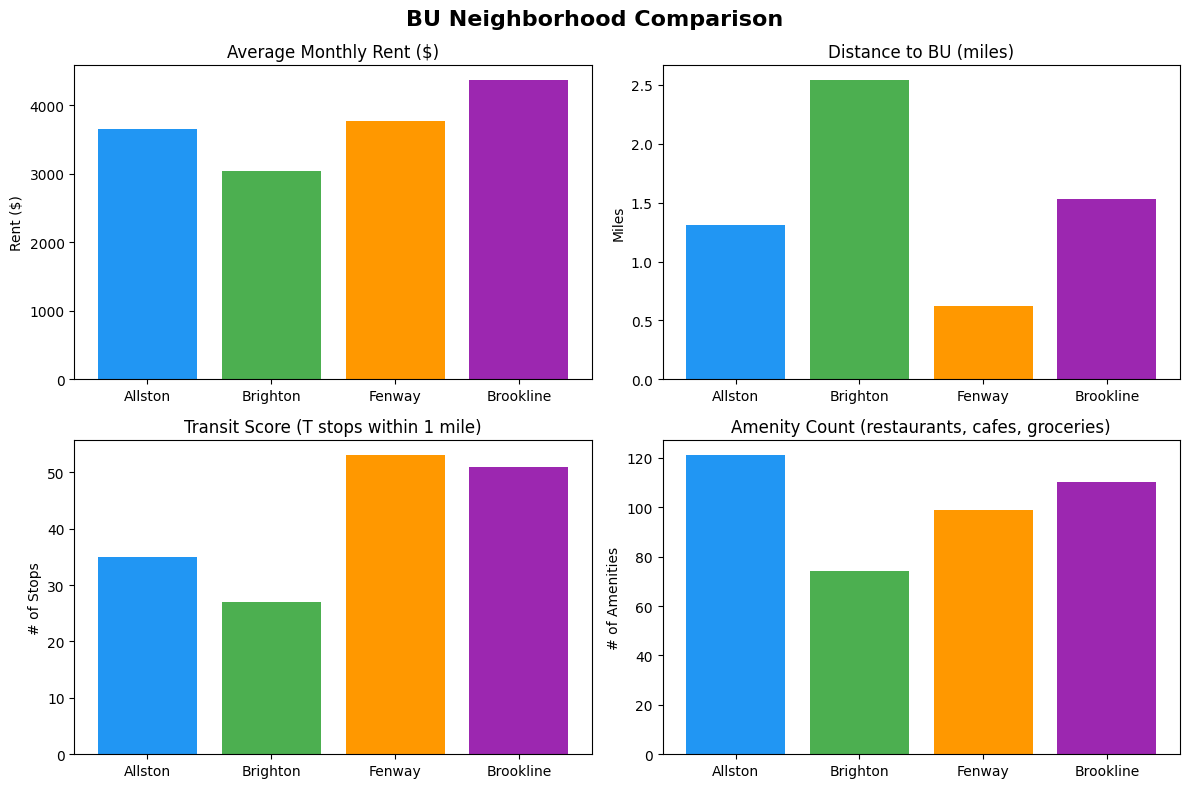

Chart saved!


In [7]:
import matplotlib.pyplot as plt
import numpy as np

bu_data = bu_master[['neighborhood', 'avg_rent', 'bu_distance_miles', 'transit_score', 'amenity_count', 'final_score']].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('BU Neighborhood Comparison', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Rent
axes[0,0].bar(bu_data['neighborhood'], bu_data['avg_rent'], color=colors)
axes[0,0].set_title('Average Monthly Rent ($)')
axes[0,0].set_ylabel('Rent ($)')

# BU Distance
axes[0,1].bar(bu_data['neighborhood'], bu_data['bu_distance_miles'], color=colors)
axes[0,1].set_title('Distance to BU (miles)')
axes[0,1].set_ylabel('Miles')

# Transit Score
axes[1,0].bar(bu_data['neighborhood'], bu_data['transit_score'], color=colors)
axes[1,0].set_title('Transit Score (T stops within 1 mile)')
axes[1,0].set_ylabel('# of Stops')

# Amenities
axes[1,1].bar(bu_data['neighborhood'], bu_data['amenity_count'], color=colors)
axes[1,1].set_title('Amenity Count (restaurants, cafes, groceries)')
axes[1,1].set_ylabel('# of Amenities')

plt.tight_layout()
plt.savefig('../outputs/neighborhood_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

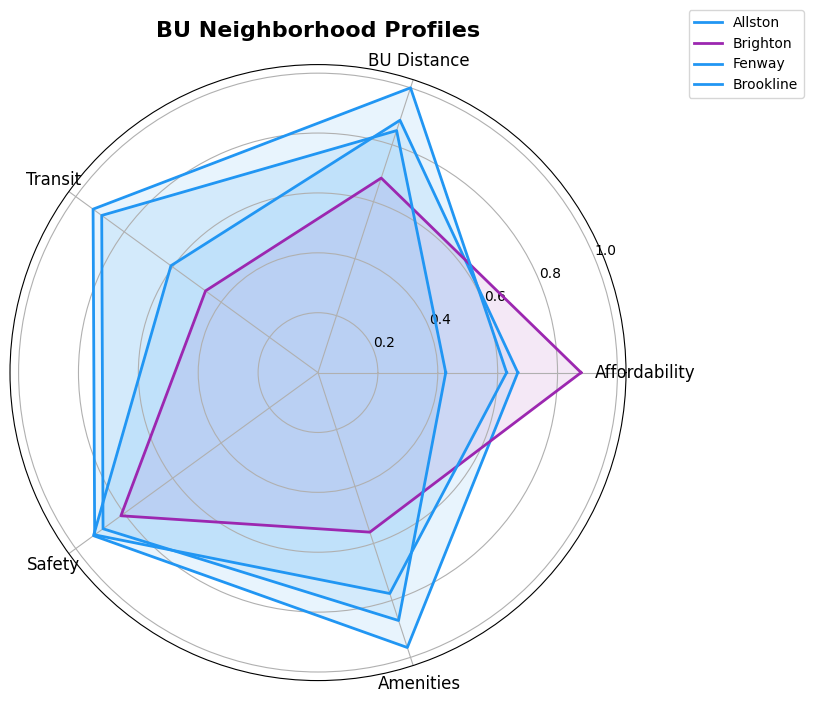

Radar chart saved!


In [8]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

# Use normalized scores for radar
categories = ['Affordability', 'BU Distance', 'Transit', 'Safety', 'Amenities']
bu_radar = bu_master[['neighborhood', 'rent_norm', 'bu_norm', 'transit_norm', 'crime_norm', 'amenity_norm']].copy()

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, row in bu_radar.iterrows():
    values = row[1:].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i % 4], linewidth=2, label=row['neighborhood'])
    ax.fill(angles, values, color=colors[i % 4], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title('BU Neighborhood Profiles', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig('../outputs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Radar chart saved!")

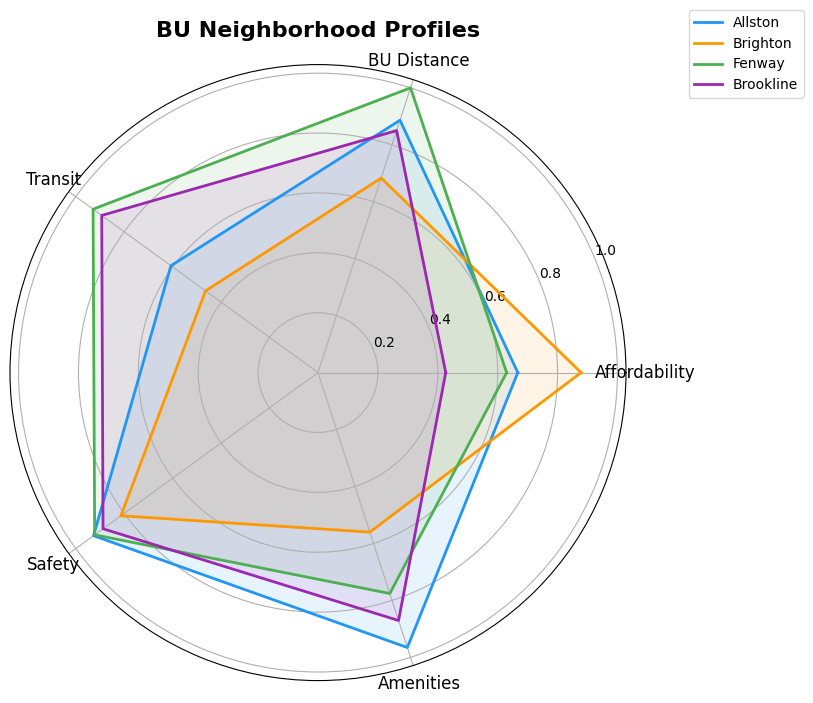

In [9]:
color_map = {
    'Allston': '#2196F3',
    'Fenway': '#4CAF50', 
    'Brighton': '#FF9800',
    'Brookline': '#9C27B0'
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in bu_radar.iterrows():
    neighborhood = row['neighborhood']
    values = row[1:].tolist()
    values += values[:1]
    color = color_map[neighborhood]
    ax.plot(angles, values, color=color, linewidth=2, label=neighborhood)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title('BU Neighborhood Profiles', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig('../outputs/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()